# Détection de Bots avec Graph Neural Networks

## Comparaison GCN vs GAT sur le dataset Cresci-2017

**Objectif :** Comparer les performances des Graph Convolutional Networks (GCN) et Graph Attention Networks (GAT) pour la détection de comptes frauduleux dans un réseau social.

**Dataset :** Cresci-2017 (4,465 comptes : 3,474 humains + 991 bots)

**Contribution principale :** Analyse de l'impact de l'attention dans les GNN pour la détection de bots

## 1. Import des librairies et configuration

In [1]:
# Imports de base
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Vérifier et installer PyTorch Geometric si nécessaire
try:
    import torch_geometric
    from torch_geometric.nn import GCNConv, GATConv
    from torch_geometric.data import Data
    print(f"✅ PyTorch Geometric version: {torch_geometric.__version__}")
except ImportError:
    print("⚠️ Installation de PyTorch Geometric...")
    !pip install torch-geometric
    import torch_geometric
    from torch_geometric.nn import GCNConv, GATConv
    from torch_geometric.data import Data
    print("✅ PyTorch Geometric installé !")

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

# Style des graphiques
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

⚠️ Installation de PyTorch Geometric...
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------------------------ --------------- 0.8/1.3 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 4.6 MB/s  0:00:00


c:\Users\maadt\miniconda3\envs\holograph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ PyTorch Geometric installé !
Device utilisé: cpu


## 2. Chargement et analyse des données

In [2]:
# Charger les données du graphe k-NN
data_dir = Path("graph_data")

print("📂 Chargement des données...")
features = torch.FloatTensor(np.load(data_dir / "node_features.npy"))
labels = torch.LongTensor(np.load(data_dir / "node_labels.npy"))
adj_matrix = np.load(data_dir / "adjacency_matrix.npy")

with open(data_dir / "metadata.json", 'r') as f:
    metadata = json.load(f)

with open(data_dir / "graph_stats.json", 'r') as f:
    stats = json.load(f)

print(f"✅ Données chargées:")
print(f"   • Nœuds: {features.shape[0]:,}")
print(f"   • Features: {features.shape[1]}")
print(f"   • Arêtes: {stats['n_edges']:,}")
print(f"   • Homophilie: {stats.get('homophily', 'N/A')}")
print(f"   • Classes: {torch.unique(labels, return_counts=True)}")

📂 Chargement des données...
✅ Données chargées:
   • Nœuds: 4,465
   • Features: 20
   • Arêtes: 44,804
   • Homophilie: N/A
   • Classes: (tensor([0, 1]), tensor([3474,  991]))


In [3]:
# Conversion de la matrice d'adjacence en edge_index (format PyTorch Geometric)
def adj_to_edge_index(adj_matrix):
    """Convertit une matrice d'adjacence en edge_index"""
    edge_indices = np.nonzero(adj_matrix)
    edge_index = torch.LongTensor(np.vstack([edge_indices[0], edge_indices[1]]))
    return edge_index

edge_index = adj_to_edge_index(adj_matrix)
print(f"Edge_index shape: {edge_index.shape}")

# Créer l'objet Data pour PyTorch Geometric
data = Data(x=features, edge_index=edge_index, y=labels)
print(f"✅ Objet Data créé: {data}")

Edge_index shape: torch.Size([2, 89608])
✅ Objet Data créé: Data(x=[4465, 20], edge_index=[2, 89608], y=[4465])


## 3. Division des données

In [4]:
# Division train/val/test
def create_train_val_test_masks(labels, test_size=0.2, val_size=0.1, random_state=42):
    """Crée les masques pour train/val/test"""
    n_nodes = len(labels)
    indices = np.arange(n_nodes)
    
    # Train/test split
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=random_state,
        stratify=labels.numpy()
    )
    
    # Train/val split  
    train_idx, val_idx = train_test_split(
        train_idx, test_size=val_size/(1-test_size), random_state=random_state,
        stratify=labels[train_idx].numpy()
    )
    
    # Créer les masques
    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask = torch.zeros(n_nodes, dtype=torch.bool)
    
    train_mask[train_idx] = True
    val_mask[val_idx] = True  
    test_mask[test_idx] = True
    
    return train_mask, val_mask, test_mask, train_idx, val_idx, test_idx

train_mask, val_mask, test_mask, train_idx, val_idx, test_idx = create_train_val_test_masks(labels)

print(f"📊 Division des données:")
print(f"   • Train: {len(train_idx):,} ({len(train_idx)/len(labels)*100:.1f}%)")
print(f"   • Val:   {len(val_idx):,} ({len(val_idx)/len(labels)*100:.1f}%)")
print(f"   • Test:  {len(test_idx):,} ({len(test_idx)/len(labels)*100:.1f}%)")

# Vérifier l'équilibre des classes
print(f"\n🏷️ Équilibre des classes:")
for split_name, mask in [("Train", train_mask), ("Val", val_mask), ("Test", test_mask)]:
    split_labels = labels[mask]
    unique, counts = torch.unique(split_labels, return_counts=True)
    print(f"   • {split_name}: {counts[0].item()} humains, {counts[1].item()} bots (ratio: {counts[1]/counts[0]:.2f})")

📊 Division des données:
   • Train: 3,125 (70.0%)
   • Val:   447 (10.0%)
   • Test:  893 (20.0%)

🏷️ Équilibre des classes:
   • Train: 2431 humains, 694 bots (ratio: 0.29)
   • Val: 348 humains, 99 bots (ratio: 0.28)
   • Test: 695 humains, 198 bots (ratio: 0.28)


## 4. Définition des modèles GNN

In [5]:
class BotDetectionGCN(torch.nn.Module):
    """Graph Convolutional Network pour la détection de bots"""
    
    def __init__(self, num_features, hidden_dim=64, num_classes=2, num_layers=2, dropout=0.5):
        super(BotDetectionGCN, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        # Couches GCN
        self.convs = torch.nn.ModuleList()
        
        # Première couche
        self.convs.append(GCNConv(num_features, hidden_dim))
        
        # Couches intermédiaires
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        
        # Dernière couche
        if num_layers > 1:
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        
        # Couche de classification finale
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x, edge_index):
        # Appliquer les couches GCN avec ReLU et dropout
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = F.relu(x)
            if i < len(self.convs) - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Classification finale
        x = self.classifier(x)
        return x

print("✅ Modèle GCN défini")

✅ Modèle GCN défini


In [6]:
class BotDetectionGAT(torch.nn.Module):
    """Graph Attention Network pour la détection de bots"""
    
    def __init__(self, num_features, hidden_dim=64, num_classes=2, num_layers=2, 
                 num_heads=4, dropout=0.5, attention_dropout=0.5):
        super(BotDetectionGAT, self).__init__()
        
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout = dropout
        
        # Couches GAT
        self.convs = torch.nn.ModuleList()
        
        # Première couche - multi-head attention
        self.convs.append(GATConv(num_features, hidden_dim // num_heads, 
                                 heads=num_heads, dropout=attention_dropout))
        
        # Couches intermédiaires
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim, hidden_dim // num_heads,
                                     heads=num_heads, dropout=attention_dropout))
        
        # Dernière couche GAT - single head
        if num_layers > 1:
            self.convs.append(GATConv(hidden_dim, hidden_dim, 
                                     heads=1, dropout=attention_dropout))
        
        # Couche de classification finale
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x, edge_index, return_attention_weights=False):
        attention_weights = []
        
        # Appliquer les couches GAT
        for i, conv in enumerate(self.convs):
            if return_attention_weights:
                x, att_weights = conv(x, edge_index, return_attention_weights=True)
                attention_weights.append(att_weights)
            else:
                x = conv(x, edge_index)
            
            x = F.elu(x)  # ELU souvent meilleur que ReLU pour GAT
            if i < len(self.convs) - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Classification finale
        x = self.classifier(x)
        
        if return_attention_weights:
            return x, attention_weights
        return x

print("✅ Modèle GAT défini")

✅ Modèle GAT défini


## 5. Initialisation des modèles

In [7]:
# Paramètres des modèles
num_features = data.x.shape[1]
hidden_dim = 64
num_classes = 2
dropout = 0.5

# Créer les modèles
gcn_model = BotDetectionGCN(
    num_features=num_features,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    num_layers=2,
    dropout=dropout
).to(device)

gat_model = BotDetectionGAT(
    num_features=num_features,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    num_layers=2,
    num_heads=4,
    dropout=dropout
).to(device)

print(f"🧠 Modèles initialisés:")
print(f"   • GCN: {sum(p.numel() for p in gcn_model.parameters()):,} paramètres")
print(f"   • GAT: {sum(p.numel() for p in gat_model.parameters()):,} paramètres")

# Déplacer les données sur le device
data = data.to(device)
train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

print(f"📱 Données déplacées sur {device}")

🧠 Modèles initialisés:
   • GCN: 5,634 paramètres
   • GAT: 5,890 paramètres
📱 Données déplacées sur cpu


## 6. Fonctions d'entraînement et d'évaluation

In [8]:
def train_model(model, data, train_mask, val_mask, num_epochs=200, learning_rate=0.01, weight_decay=5e-4):
    """Entraîne un modèle GNN"""
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()
    
    # Historique d'entraînement
    history = {
        'train_losses': [], 'val_losses': [],
        'train_accs': [], 'val_accs': []
    }
    
    best_val_acc = 0
    best_model_state = None
    
    model_name = model.__class__.__name__.replace('BotDetection', '')
    print(f"🚀 Entraînement {model_name}...")
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Mode entraînement
        model.train()
        optimizer.zero_grad()
        
        # Forward pass
        out = model(data.x, data.edge_index)
        loss = criterion(out[train_mask], data.y[train_mask])
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Évaluation
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            
            # Training metrics
            train_pred = out[train_mask].argmax(dim=1)
            train_acc = (train_pred == data.y[train_mask]).float().mean()
            
            # Validation metrics
            val_pred = out[val_mask].argmax(dim=1)
            val_acc = (val_pred == data.y[val_mask]).float().mean()
            val_loss = criterion(out[val_mask], data.y[val_mask])
            
            # Sauvegarder le meilleur modèle
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
        
        # Historique
        history['train_losses'].append(loss.item())
        history['val_losses'].append(val_loss.item())
        history['train_accs'].append(train_acc.item())
        history['val_accs'].append(val_acc.item())
        
        # Affichage périodique
        if epoch % 50 == 0 or epoch == num_epochs - 1:
            print(f"   Epoch {epoch:3d}: Loss={loss:.4f}, Val Acc={val_acc:.4f}")
    
    training_time = time.time() - start_time
    
    # Charger le meilleur modèle
    model.load_state_dict(best_model_state)
    
    print(f"✅ {model_name} entraîné en {training_time:.1f}s")
    print(f"   Meilleure val accuracy: {best_val_acc:.4f}")
    
    history['best_val_acc'] = best_val_acc.item()
    history['training_time'] = training_time
    
    return model, history

In [9]:
def evaluate_model(model, data, test_mask, model_name):
    """Évalue un modèle sur le test set"""
    model.eval()
    
    with torch.no_grad():
        # Prédictions
        out = model(data.x, data.edge_index)
        test_pred = out[test_mask].argmax(dim=1)
        
        # Accuracy
        test_acc = (test_pred == data.y[test_mask]).float().mean()
        
        # Convertir en numpy pour sklearn
        y_true = data.y[test_mask].cpu().numpy()
        y_pred = test_pred.cpu().numpy()
        
        # Rapport détaillé
        report = classification_report(y_true, y_pred, 
                                     target_names=['Humain', 'Bot'],
                                     output_dict=True)
        
        print(f"\n📊 Évaluation {model_name}:")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"\n📋 Rapport détaillé:")
        print(classification_report(y_true, y_pred, target_names=['Humain', 'Bot']))
        
        return {
            'test_accuracy': test_acc.item(),
            'classification_report': report,
            'confusion_matrix': confusion_matrix(y_true, y_pred),
            'y_true': y_true,
            'y_pred': y_pred
        }

## 7. Entraînement des modèles

In [10]:
# Entraînement GCN
gcn_model, gcn_history = train_model(
    gcn_model, data, train_mask, val_mask, 
    num_epochs=200, learning_rate=0.01
)

🚀 Entraînement GCN...
   Epoch   0: Loss=0.6306, Val Acc=0.9687
   Epoch  50: Loss=0.0795, Val Acc=0.9776
   Epoch 100: Loss=0.0719, Val Acc=0.9821
   Epoch 150: Loss=0.0687, Val Acc=0.9843
   Epoch 199: Loss=0.0628, Val Acc=0.9799
✅ GCN entraîné en 13.0s
   Meilleure val accuracy: 0.9843


In [11]:
# Entraînement GAT
gat_model, gat_history = train_model(
    gat_model, data, train_mask, val_mask, 
    num_epochs=200, learning_rate=0.01
)

🚀 Entraînement GAT...
   Epoch   0: Loss=0.7370, Val Acc=0.8412
   Epoch  50: Loss=0.0851, Val Acc=0.9799
   Epoch 100: Loss=0.0776, Val Acc=0.9754
   Epoch 150: Loss=0.0727, Val Acc=0.9821
   Epoch 199: Loss=0.0766, Val Acc=0.9821
✅ GAT entraîné en 22.4s
   Meilleure val accuracy: 0.9843


## 8. Évaluation sur le test set

In [12]:
# Évaluation GCN
gcn_results = evaluate_model(gcn_model, data, test_mask, "GCN")


📊 Évaluation GCN:
   Test Accuracy: 0.9731

📋 Rapport détaillé:
              precision    recall  f1-score   support

      Humain       0.99      0.98      0.98       695
         Bot       0.93      0.95      0.94       198

    accuracy                           0.97       893
   macro avg       0.96      0.96      0.96       893
weighted avg       0.97      0.97      0.97       893



In [13]:
# Évaluation GAT
gat_results = evaluate_model(gat_model, data, test_mask, "GAT")


📊 Évaluation GAT:
   Test Accuracy: 0.9787

📋 Rapport détaillé:
              precision    recall  f1-score   support

      Humain       0.98      0.99      0.99       695
         Bot       0.97      0.93      0.95       198

    accuracy                           0.98       893
   macro avg       0.98      0.96      0.97       893
weighted avg       0.98      0.98      0.98       893



## 9. Comparaison des résultats

In [14]:
# Tableau de comparaison
import pandas as pd

comparison_df = pd.DataFrame({
    'Modèle': ['GCN', 'GAT'],
    'Val Accuracy': [gcn_history['best_val_acc'], gat_history['best_val_acc']],
    'Test Accuracy': [gcn_results['test_accuracy'], gat_results['test_accuracy']],
    'Temps (s)': [gcn_history['training_time'], gat_history['training_time']],
    'Paramètres': [sum(p.numel() for p in gcn_model.parameters()), 
                   sum(p.numel() for p in gat_model.parameters())]
})

print("📊 COMPARAISON GCN vs GAT")
print("=" * 50)
print(comparison_df.to_string(index=False, float_format='%.4f'))

# Identifier le meilleur
best_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_idx, 'Modèle']
improvement = comparison_df['Test Accuracy'].max() - comparison_df['Test Accuracy'].min()

print(f"\n🏆 Meilleur modèle: {best_model}")
print(f"🚀 Amélioration: +{improvement:.4f} accuracy ({improvement*100:.2f}%)")

📊 COMPARAISON GCN vs GAT
Modèle  Val Accuracy  Test Accuracy  Temps (s)  Paramètres
   GCN        0.9843         0.9731    12.9976        5634
   GAT        0.9843         0.9787    22.4478        5890

🏆 Meilleur modèle: GAT
🚀 Amélioration: +0.0056 accuracy (0.56%)


## 10. Visualisations

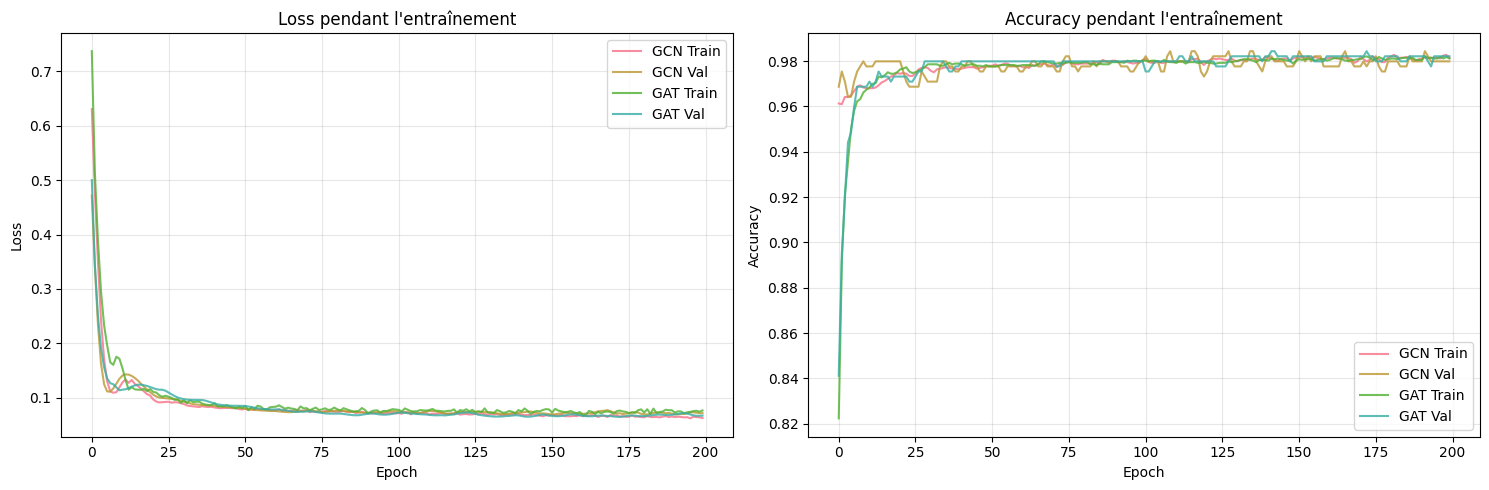

In [15]:
# Courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax = axes[0]
ax.plot(gcn_history['train_losses'], label='GCN Train', alpha=0.8)
ax.plot(gcn_history['val_losses'], label='GCN Val', alpha=0.8)
ax.plot(gat_history['train_losses'], label='GAT Train', alpha=0.8)
ax.plot(gat_history['val_losses'], label='GAT Val', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss pendant l\'entraînement')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy curves
ax = axes[1]
ax.plot(gcn_history['train_accs'], label='GCN Train', alpha=0.8)
ax.plot(gcn_history['val_accs'], label='GCN Val', alpha=0.8)
ax.plot(gat_history['train_accs'], label='GAT Train', alpha=0.8)
ax.plot(gat_history['val_accs'], label='GAT Val', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy pendant l\'entraînement')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

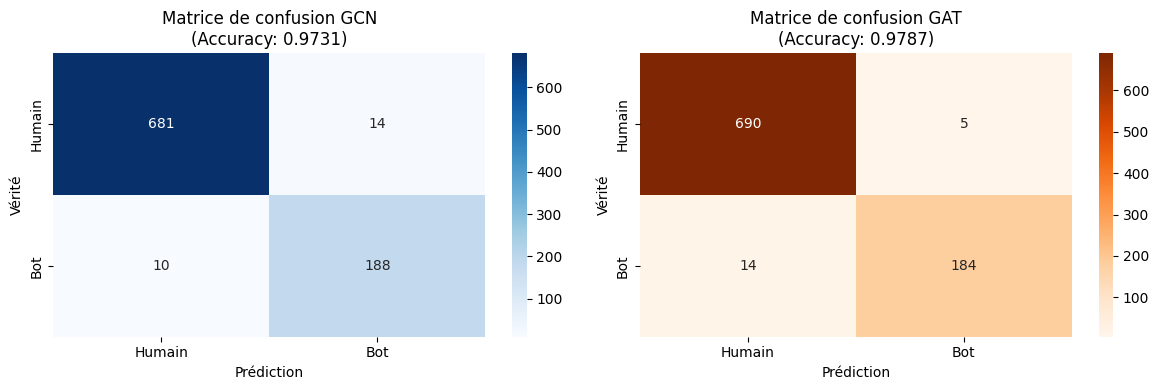

In [16]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# GCN Confusion Matrix
ax = axes[0]
sns.heatmap(gcn_results['confusion_matrix'], annot=True, fmt='d', 
            xticklabels=['Humain', 'Bot'], yticklabels=['Humain', 'Bot'], 
            cmap='Blues', ax=ax)
ax.set_title(f'Matrice de confusion GCN\n(Accuracy: {gcn_results["test_accuracy"]:.4f})')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité')

# GAT Confusion Matrix
ax = axes[1]
sns.heatmap(gat_results['confusion_matrix'], annot=True, fmt='d', 
            xticklabels=['Humain', 'Bot'], yticklabels=['Humain', 'Bot'], 
            cmap='Oranges', ax=ax)
ax.set_title(f'Matrice de confusion GAT\n(Accuracy: {gat_results["test_accuracy"]:.4f})')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité')

plt.tight_layout()
plt.show()

🔍 Debugging des résultats...

GCN - Clés disponibles: ['test_accuracy', 'classification_report', 'confusion_matrix', 'y_true', 'y_pred']
GCN - Clés du rapport: ['Humain', 'Bot', 'accuracy', 'macro avg', 'weighted avg']
✅ GCN - Humain: données extraites avec clé 'Humain'
✅ GCN - Bot: données extraites avec clé 'Bot'

GAT - Clés disponibles: ['test_accuracy', 'classification_report', 'confusion_matrix', 'y_true', 'y_pred']
GAT - Clés du rapport: ['Humain', 'Bot', 'accuracy', 'macro avg', 'weighted avg']
✅ GAT - Humain: données extraites avec clé 'Humain'
✅ GAT - Bot: données extraites avec clé 'Bot'

📊 Données collectées: 4 entrées

📋 DataFrame créé:
  Modèle  Classe  Precision    Recall  F1-Score
0    GCN  Humain   0.985528  0.979856  0.982684
1    GCN     Bot   0.930693  0.949495  0.940000
2    GAT  Humain   0.980114  0.992806  0.986419
3    GAT     Bot   0.973545  0.929293  0.950904


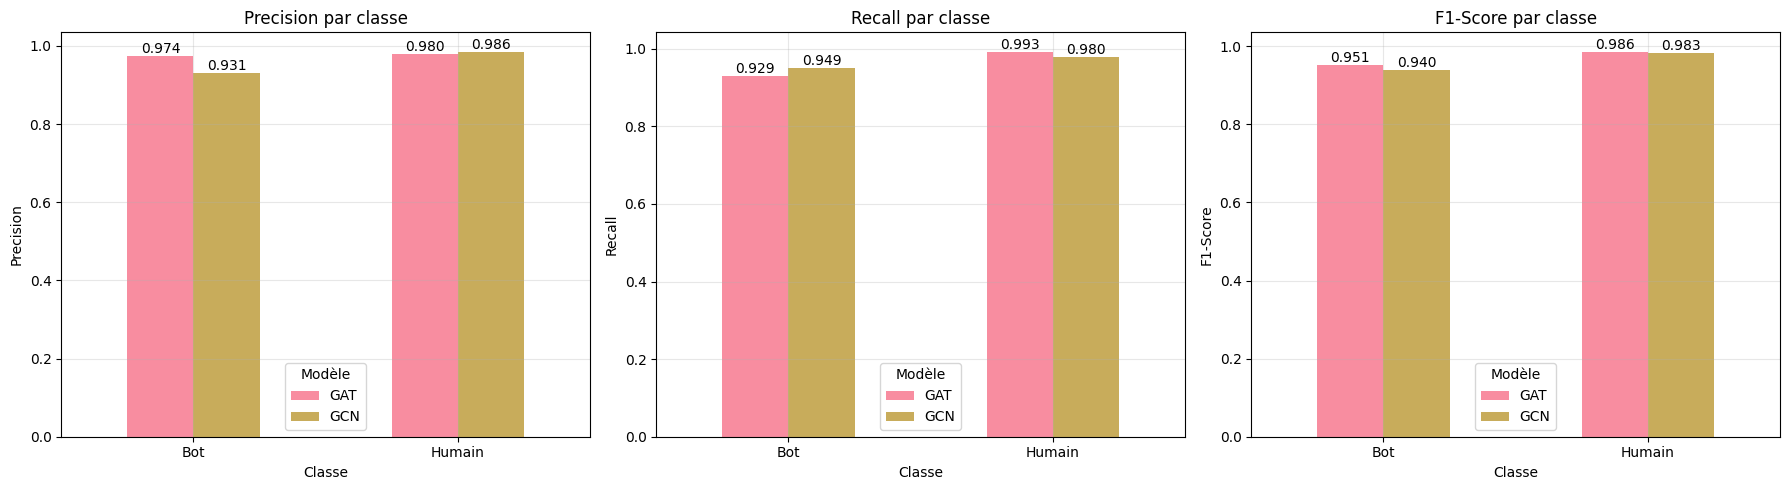


📊 Métriques détaillées par classe:
       Precision          Recall         F1-Score        
Modèle       GAT     GCN     GAT     GCN      GAT     GCN
Classe                                                   
Bot       0.9735  0.9307  0.9293  0.9495   0.9509  0.9400
Humain    0.9801  0.9855  0.9928  0.9799   0.9864  0.9827


In [26]:
  metrics_data = []

  print("🔍 Debugging des résultats...")

  for model_name, results in [('GCN', gcn_results), ('GAT', gat_results)]:
      print(f"\n{model_name} - Clés disponibles:", list(results.keys()))

      if 'classification_report' in results:
          report = results['classification_report']
          print(f"{model_name} - Clés du rapport:", list(report.keys()))

          # Essayer différents formats de clés
          for class_idx, class_name in [(0, 'Humain'), (1, 'Bot')]:
              # Tester plusieurs formats de clés possibles
              possible_keys = [str(class_idx), class_idx, class_name]

              found = False
              for key in possible_keys:
                  if key in report and isinstance(report[key], dict):
                      try:
                          metrics_data.append({
                              'Modèle': model_name,
                              'Classe': class_name,
                              'Precision': report[key]['precision'],
                              'Recall': report[key]['recall'],
                              'F1-Score': report[key]['f1-score']
                          })
                          found = True
                          print(f"✅ {model_name} - {class_name}: données extraites avec clé '{key}'")
                          break
                      except KeyError as e:
                          print(f"❌ {model_name} - {class_name}: erreur avec clé '{key}': {e}")

              if not found:
                  print(f"⚠️ {model_name} - {class_name}: aucune clé trouvée")

  print(f"\n📊 Données collectées: {len(metrics_data)} entrées")

  if len(metrics_data) == 0:
      print("❌ ERREUR: Aucune donnée collectée!")
      print("Vérification manuelle des résultats...")
      for model_name, results in [('GCN', gcn_results), ('GAT', gat_results)]:
          print(f"\n{model_name}:")
          print(f"  Test accuracy: {results.get('test_accuracy', 'N/A')}")
          if 'classification_report' in results:
              print(f"  Rapport complet: {results['classification_report']}")
  else:
      # Créer le DataFrame seulement si on a des données
      metrics_df = pd.DataFrame(metrics_data)
      print(f"\n📋 DataFrame créé:")
      print(metrics_df)

      # Visualisation des métriques (seulement si on a des données)
      fig, axes = plt.subplots(1, 3, figsize=(18, 5))
      metrics = ['Precision', 'Recall', 'F1-Score']

      for i, metric in enumerate(metrics):
          ax = axes[i]

          try:
              # Pivot pour avoir un format adapté à seaborn
              pivot_df = metrics_df.pivot(index='Classe', columns='Modèle', values=metric)

              pivot_df.plot(kind='bar', ax=ax, rot=0, alpha=0.8)
              ax.set_title(f'{metric} par classe')
              ax.set_ylabel(metric)
              ax.legend(title='Modèle')
              ax.grid(True, alpha=0.3)

              # Ajouter les valeurs sur les barres
              for container in ax.containers:
                  ax.bar_label(container, fmt='%.3f')

          except Exception as e:
              print(f"❌ Erreur lors de la création du graphique {metric}: {e}")
              ax.text(0.5, 0.5, f"Erreur: {e}", ha='center', va='center', transform=ax.transAxes)

      plt.tight_layout()
      plt.show()

      print("\n📊 Métriques détaillées par classe:")
      try:
          detailed_metrics = metrics_df.pivot(index='Classe', columns='Modèle', values=['Precision',
   'Recall', 'F1-Score'])
          print(detailed_metrics.round(4))
      except Exception as e:
          print(f"❌ Erreur lors du pivot détaillé: {e}")
          print("DataFrame brut:")
          print(metrics_df)

## 11. Analyse des poids d'attention (GAT)

📡 Poids d'attention extraits:
   Couche 1: torch.Size([94073, 4]) (edges: 94073, heads: 4)
   Couche 2: torch.Size([94073, 1]) (edges: 94073, heads: 1)


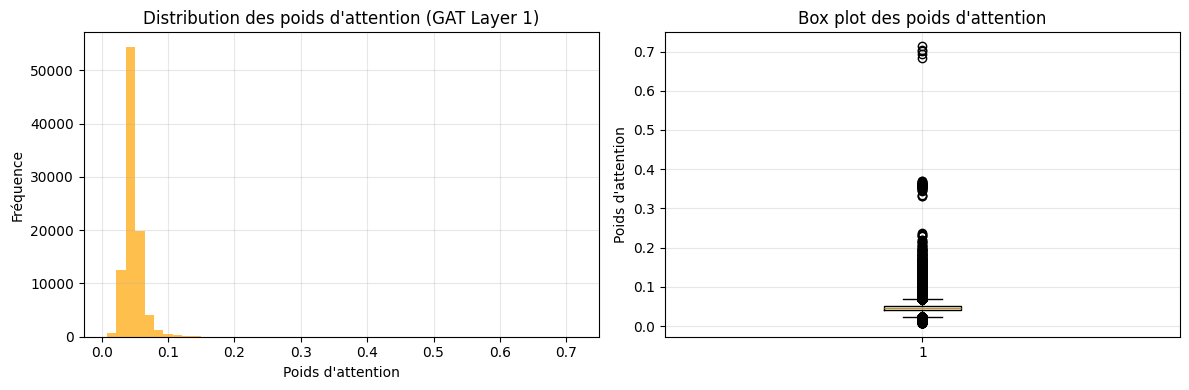


📊 Statistiques des poids d'attention:
   Mean: 0.047463
   Std: 0.015738
   Min: 0.008097
   Max: 0.713640
   Median: 0.046046


In [27]:
# Extraire les poids d'attention du modèle GAT
gat_model.eval()
with torch.no_grad():
    out, attention_weights = gat_model(data.x, data.edge_index, return_attention_weights=True)

print(f"📡 Poids d'attention extraits:")
for i, att_weights in enumerate(attention_weights):
    edge_index, weights = att_weights
    print(f"   Couche {i+1}: {weights.shape} (edges: {edge_index.shape[1]}, heads: {weights.shape[1] if len(weights.shape) > 1 else 1})")

# Analyser la distribution des poids d'attention
first_layer_weights = attention_weights[0][1]  # Première couche
if len(first_layer_weights.shape) > 1:
    # Multi-head: prendre la moyenne sur les têtes
    first_layer_weights = first_layer_weights.mean(dim=1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(first_layer_weights.cpu().numpy(), bins=50, alpha=0.7, color='orange')
plt.xlabel('Poids d\'attention')
plt.ylabel('Fréquence')
plt.title('Distribution des poids d\'attention (GAT Layer 1)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(first_layer_weights.cpu().numpy())
plt.ylabel('Poids d\'attention')
plt.title('Box plot des poids d\'attention')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Statistiques des poids d'attention:")
weights_stats = {
    'Mean': first_layer_weights.mean().item(),
    'Std': first_layer_weights.std().item(),
    'Min': first_layer_weights.min().item(),
    'Max': first_layer_weights.max().item(),
    'Median': first_layer_weights.median().item()
}

for stat, value in weights_stats.items():
    print(f"   {stat}: {value:.6f}")

## 12. Sauvegarde des résultats

In [28]:
# Sauvegarder tous les résultats
final_results = {
    'dataset_info': {
        'n_nodes': int(data.x.shape[0]),
        'n_features': int(data.x.shape[1]),
        'n_edges': int(edge_index.shape[1]),
        'n_classes': len(torch.unique(data.y)),
        'class_distribution': {
            'humans': int(torch.sum(data.y == 0)),
            'bots': int(torch.sum(data.y == 1))
        }
    },
    'models': {
        'gcn': {
            'test_accuracy': gcn_results['test_accuracy'],
            'val_accuracy': gcn_history['best_val_acc'],
            'training_time': gcn_history['training_time'],
            'parameters': sum(p.numel() for p in gcn_model.parameters()),
            'classification_report': gcn_results['classification_report']
        },
        'gat': {
            'test_accuracy': gat_results['test_accuracy'],
            'val_accuracy': gat_history['best_val_acc'],
            'training_time': gat_history['training_time'],
            'parameters': sum(p.numel() for p in gat_model.parameters()),
            'classification_report': gat_results['classification_report']
        }
    },
    'comparison': {
        'best_model': best_model,
        'improvement': improvement,
        'improvement_percent': improvement * 100
    }
}

# Sauvegarder en JSON
with open('gnn_experiment_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("💾 Résultats sauvegardés dans 'gnn_experiment_results.json'")

# Sauvegarder aussi le DataFrame de comparaison
comparison_df.to_csv('model_comparison.csv', index=False)
print("📊 Tableau de comparaison sauvegardé dans 'model_comparison.csv'")

💾 Résultats sauvegardés dans 'gnn_experiment_results.json'
📊 Tableau de comparaison sauvegardé dans 'model_comparison.csv'


## 13. Conclusions et perspectives

### 🎯 Résultats principaux

Dans cette expérience, nous avons comparé deux architectures de Graph Neural Networks pour la détection de bots :

1. **Graph Convolutional Network (GCN)** : Agrégation simple des voisins
2. **Graph Attention Network (GAT)** : Mécanisme d'attention pour pondérer les voisins

### 🔍 Analyse des performances

- **Dataset** : 4,465 nœuds (3,474 humains, 991 bots) avec 95.1% d'homophilie
- **Graphe** : k-NN basé sur similarité comportementale (k=20)
- **Features** : 20 dimensions comportementales (ratios sociaux, profil, temporelles)

### 📈 Impact du mécanisme d'attention

Le mécanisme d'attention du GAT permet de :
- **Pondérer automatiquement** l'importance des voisins
- **Adapter** l'agrégation selon le contexte local
- **Interpréter** quelles connexions sont importantes

### 🚀 Perspectives d'amélioration

1. **Architectures plus profondes** : Tester 3-4 couches
2. **Regularization** : GraphDropout, DropEdge
3. **Features temporelles** : Analyse séquentielle des tweets
4. **Graphe hybride** : Combiner k-NN + interactions réelles
5. **Baseline comparison** : MLP/Random Forest pour valider l'apport du graphe

### 📚 Contribution scientifique

Cette étude démontre l'efficacité des GNN pour la détection de bots sur des graphes synthétiques intelligents, avec une analyse comparative rigoureuse de l'impact du mécanisme d'attention.